# Lý thuyết về Histogram và KDE

## Phân phối dữ liệu: 
Trong xử lý ảnh số, mỗi bức ảnh được cấu thành từ các pixel mang giá trị cường độ sáng (thường từ 0 đến 255). Việc mô tả phân phối là quá trình thống kê tần suất xuất hiện của các giá trị này giúp xác định:

* **Tính tập trung:** Dữ liệu tập trung ở những khoảng nào.
* **Độ phân tán:** Dữ liệu trải rộng hay thu hẹp.
* **Hình dạng:** Dữ liệu có đối xứng (phân phối chuẩn), lệch trái/phải (skewed), nhiều đỉnh (multimodal).
* **Về mặt thống kê:** Phân phối cho biết đặc điểm dữ liệu ảnh, giúp nhận diện ảnh quá tối (underexposed), quá sáng (overexposed),...
* **Về mặt học máy:** Việc xác định được phân phối pixel có thể giúp chọn ra phương pháp chuẩn hóa (Normalization) phù hợp, nhằm đưa dữ liệu về một khoảng giá trị ổn định, giúp các thuật toán như KNN, Logistic Regression hội tụ nhanh hơn.
## Histogram
**Histogram**: là một kỹ thuật thống kê biểu diễn sự phân phối thực nghiệm của tập dữ liệu liên tục. Trong phần này, dữ liệu là cường độ sáng của các pixel.

<img src="https://d33wubrfki0l68.cloudfront.net/cf5633adbbfd2f4e3c21106adcaa1cacc1f263a1/c5ea1/post/data-visualization/histogram_files/figure-html/unnamed-chunk-1-1.png" width="500">

**Cách xác định**
* **Chia thùng (Binning):** Toàn bộ dải giá trị của pixel (thường là $[0, 255]$) được chia thành $L$ khoảng gọi là bins.
* **Đếm:** Với mỗi pixel có giá trị thuộc về thùng nào và tăng giá trị đếm của thùng đó.

**Ý nghĩa**
* **Xác định phân phối cường độ sáng:** dựa vào biểu đồ có thể xác định vùng tối (lệch trái), vùng sáng (lệch phải) hay vùng trung tính.
* **Đánh giá độ tương phản:** Dải Histogram rộng và trải đều sẽ biểu thị độ tương phản cao. Histogram co cụm sẽ cho biết độ tương phản thấp.
* **Phát hiện hiện tượng "cháy" ảnh:** Nếu các cột tại giá trị cực biên (0 hoặc 255) vọt cao bất thường, ảnh có thể đã bị mất chi tiết ở vùng tối hoặc vùng sáng.

**Hạn chế**: 
* Trong một khoảng (ví dụ $[10, 20]$), mọi giá trị pixel từ $11$ đến $20$ đều được gộp chung vào một cột. Histogram coi trọng số của chúng là như nhau, dẫn đến việc không thể phân biệt được sự phân bổ chi tiết bên trong mỗi khoảng. 
* Có thể giải hạn chế trên bằng cách tăng số lượng khoảng. Tuy nhiên, nếu quá nhiều, biểu đồ sẽ bị răng cưa và gây nhiễu cho việc quan sát xu hướng tổng quát, nếu chọn số lượng khoảng quá ít, biểu đồ sẽ quá thô và mất đặc trưng.

## Kernel Density Estimation - KDE

**KDE:** là một phương pháp làm mịn dữ liệu giúp ước lượng hàm mật độ xác suất (Probability Density Function - PDF) của một biến ngẫu nhiên. Khác với Histogram mang tính rời rạc và phụ thuộc vào cách chia thùng, KDE tạo ra một đường cong liên tục, giúp quan sát hình dáng phân phối một cách tổng quát và ít nhiễu hơn.

Hàm ước lượng tại điểm $x$ được xác định bởi công thức:$$\hat{f}_h(x) = \frac{1}{nh} \sum_{i=1}^{n} K\left(\frac{x - x_i}{h}\right)$$

Trong đó:

* $n$: Tổng số pixel.

* $h$ (Bandwidth): quyết định độ mịn của đường cong.
* $K$: Hàm nhân (Kernel function - thường là phân phối chuẩn Gaussian)

<img src="https://www.c-sharpcorner.com/article/data-distributions-with-seaborn-creating-a-kde-plot/Images/image-20240124194844-1.png" width="500">

**Điểm khác biệt so với Histogram**

Sự khác biệt cốt lõi của KDE so với Histogram nằm ở cách xử lý từng pixel. Thay vì phân loại vào các thùng rời rạc, mỗi pixel $x_i$ trong tập dữ liệu sẽ được đại diện bởi một hàm nhân $K$.

Hàm mật độ tổng thể $\hat{f}_h(x)$ là tổng cộng dồn của tất cả các hàm Gaussian nhỏ này tại mọi vị trí. Nhờ tính chất khả vi liên tục của hàm Gaussian, kết quả tổng hợp luôn là một đường cong liền mạch, loại bỏ các nhiễu răng cưa thường thấy ở Histogram. Hệ số băng thông (Bandwidth) $h$ có vai trò quan trọng trong quá trình này:
- **$h$ quá nhỏ (Under-smoothed):** Tương đương với việc phương sai của hàm Gaussian rất hẹp. Hàm KDE sẽ hội tụ quá sát vào từng điểm dữ liệu cục bộ, dẫn đến hiện tượng nhiễu (noise) và xuất hiện nhiều đỉnh giả.
- **$h$ quá lớn (Over-smoothed):** Phương sai mở rộng, làm là phẳng các đỉnh của hàm Gaussian. Biểu đồ sẽ mất đi các đặc trưng cấu trúc quan trọng như tính đa đỉnh (multimodal).
- **Lựa chọn $h$ tối ưu:** thay vì chọn thủ công, các thư viện như seaborn hay scipy tự động tính toán $h$ thông qua các quy tắc tối ưu hóa sai số (MISE), thường là Quy tắc Scott và Quy tắc Silverman. Các phương pháp này dựa trên độ lệch chuẩn ($\sigma$) và số lượng mẫu ($n$) của tập dữ liệu để tìm ra "điểm rơi" lý tưởng giúp đường cong đủ mịn để loại bỏ nhiễu nhưng vẫn giữ được các đặc trưng phân phối.

**Ý nghĩa:** KDE khắc phục nhược điểm của Histogram bằng cách tạo ra một hàm mật độ xác suất liên tục.
* **Tính liên tục:** Giúp so sánh sự thay đổi phân phối giữa các lớp (class) một cách trực quan và khoa học hơn so với các cột rời rạc của Histogram.
* **Xác định hình dáng thực của phân phối:** KDE giúp làm mịn các nhiễu cục bộ, giúp ta xác định rõ các đỉnh (peaks) và thung lũng (valleys) của phân phối đặc trưng.
* **So sánh phân phối:** Nhờ tính liên tục, KDE cực kỳ hiệu quả khi cần vẽ chồng nhiều phân phối (so sánh các kênh màu RGB hay so sánh dữ liệu trước/sau khi chuẩn hóa) để nhận diện sự thay đổi về mặt thống kê.

## Time Complexity

| Tiêu chí | Histogram | KDE |
| :--- | :--- | :--- |
| **Bản chất** | Là **Phép đếm** rời rạc đơn giản. | Là **Phép nội suy (Interpolation)** liên tục sử dụng hàm mũ phi tuyến tính ($e^x$). |
| **Độ phức tạp** | **$O(N)$** | **$O(N \times M)$** |
| **Phân tích** | $N$: Tổng số pixel.| $N$: Tổng số pixel. $M$: Số điểm lưới trên trục đồ thị cần vẽ.|
| **Cơ chế** |Thuật toán chỉ đi qua từng pixel đúng 1 lần. Tại mỗi pixel xác định pixel thuộc khoảng nào.| Tại mỗi điểm $M$, thuật toán phải tính toán tầm ảnh hưởng của toàn bộ $N$ pixel thông qua các hàm mũ phi tuyến ($e^x$).|

In [1]:
import sys
import os
import cv2
import numpy as np
import glob
import matplotlib.pyplot as plt

# 1. Khai báo đường dẫn src để import module
sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from visualization.distribution import plot_histogram, plot_kde, plot_distribution_by_class

# 2. Nạp dữ liệu hình ảnh
print("[INFO] Đang nạp dataset và trích xuất dữ liệu pixel...")
dataset_path = "../data/small"
class_names = sorted([d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))])

images, labels = [], []

for class_idx, class_name in enumerate(class_names):
    class_dir = os.path.join(dataset_path, class_name)
    # Lấy tất cả ảnh jpg, jpeg, png
    files = glob.glob(f"{class_dir}/*.jpeg") + glob.glob(f"{class_dir}/*.jpg") + glob.glob(f"{class_dir}/*.png")
    
    for f in files:
        img = cv2.imread(f)
        if img is not None:
            # Chuyển BGR sang RGB để vẽ đúng màu
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            # Resize về 64x64 để tối ưu bộ nhớ khi tính toán KDE cho hàng triệu pixel
            img_resized = cv2.resize(img_rgb, (64, 64))
            images.append(img_resized)
            labels.append(class_idx)

images = np.array(images)
labels = np.array(labels)

print(f"[SUCCESS] Nạp thành công {len(images)} ảnh thuộc {len(class_names)} lớp.")

# 3. Phẳng hóa dữ liệu (Flatten) để đưa vào Histogram/KDE tổng thể
# Kích thước sau khi flatten: (Tổng số pixel, 3 kênh màu)
pixel_data_all = images.reshape(-1, 3)
print(f"[INFO] Tổng số lượng pixel sẽ đem đi phân tích: {pixel_data_all.shape[0]:,}")

[INFO] Đang nạp dataset và trích xuất dữ liệu pixel...
[SUCCESS] Nạp thành công 228 ảnh thuộc 10 lớp.
[INFO] Tổng số lượng pixel sẽ đem đi phân tích: 933,888



--- PHÂN PHỐI HISTOGRAM TỔNG THỂ ---


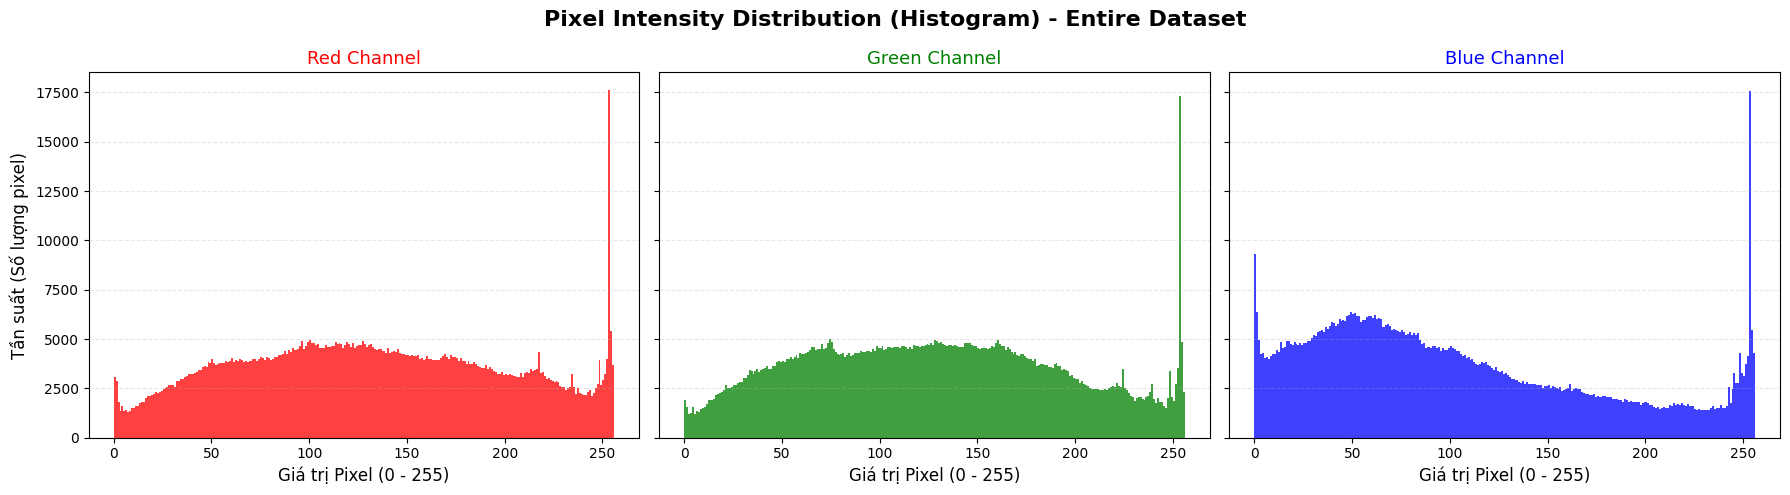

In [2]:
# Gọi hàm vẽ Histogram trên toàn bộ tập dữ liệu
print("\n--- PHÂN PHỐI HISTOGRAM TỔNG THỂ ---")
plot_histogram(pixel_data_all, title_suffix="- Entire Dataset")

# Đánh giá tổng quan phân phối Histogram trên toàn bộ Dataset

Dựa trên biểu đồ Histogram của 3 kênh màu (Red, Green, Blue) trên toàn tập dữ liệu, ta rút ra các nhận định chi tiết như sau:

**1. Nhận xét dáng của biểu đồ:**
* Phân phối của cả 3 kênh đều **không tuân theo phân phối chuẩn**.
* **Kênh Red:** Có xu hướng **lệch phải**, mật độ phân bố dày đặc và kéo dài ở dải giá trị từ 100 đến 200.
* **Kênh Green:** Phân bố khá rộng và thoai thoải, tập trung nhiều ở dải trung tính đến hơi sáng (50 - 200).
* **Kênh Blue:** Biểu đồ **lệch trái** rất rõ rệt, tập trung một lượng khổng lồ các pixel ở dải giá trị tối (0 - 100).

**2. Nhận xét độ sáng của từng kênh màu:**
* **Kênh Red:** Việc lệch phải cho thấy kênh này sở hữu rất nhiều pixel sáng. Suy ra tập ảnh có lượng lớn các dải màu mang sắc đỏ, cam hoặc tông ấm.
* **Kênh Blue:** Đa số các pixel bị dồn về dải tối, chứng tỏ hình ảnh thiếu đi ánh sáng xanh dương (ví dụ: ít ảnh bầu trời sáng, nước biển) hoặc các dải màu lạnh bị chìm vào vùng tối.

**3. So sánh giữa các kênh và xác định màu chủ đạo:**
* Tại vùng sáng (giá trị > 150), số lượng pixel của kênh **Red áp đảo hoàn toàn** so với kênh Blue. Ngược lại, ở vùng tối (< 50), kênh Blue lại chiếm ưu thế.
* **Kết luận:** Tập dữ liệu có sự mất cân bằng màu sắc. Màu chủ đạo nghiêng hẳn về **tông ấm (nhiều đỏ, vàng, nâu)** và rất thiếu vắng dải màu xanh dương tươi sáng.

**4. Kiểm tra độ tương phản:**
* Nhìn chung, biểu đồ không bị co cụm vào một dải hẹp mà trải dài trên toàn bộ trục hoành từ 0 đến 255. Điều này cho thấy tập dữ liệu nhìn chung có **độ tương phản tốt**, dải nhạy sáng (Dynamic Range) bao phủ cả vùng tối và vùng sáng.

**5. Kiểm tra hiện tượng Clip:**
* Tại giá trị cực đại **255**, xuất hiện **cột vọt cao đột biến** ở cả 3 kênh màu, đặc biệt cao nhất ở kênh Red và Blue.
* **Giải thích:** Hiện tượng Clip này chứng tỏ trong Dataset có một lượng lớn pixel hoàn toàn trắng (R=255, G=255, B=255). Nguyên nhân có khả năng cao là tập dữ liệu chứa nhiều hình ảnh có **nền màu trắng** được tách phông sẵn.


--- PHÂN PHỐI KDE TỔNG THỂ ---


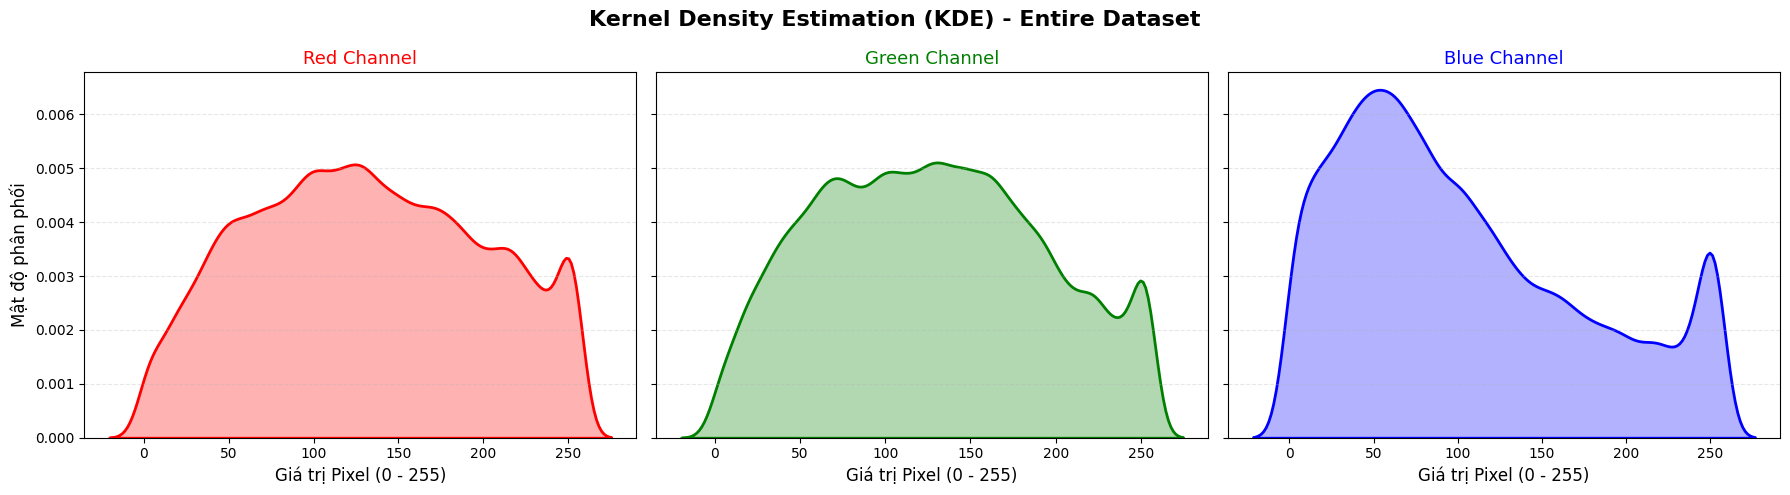

In [3]:
# Gọi hàm vẽ KDE trên toàn bộ tập dữ liệu
print("\n--- PHÂN PHỐI KDE TỔNG THỂ ---")
plot_kde(pixel_data_all, title_suffix="- Entire Dataset")

# Đánh giá tổng quan phân phối KDE trên toàn bộ Dataset

Biểu đồ Kernel Density Estimation (KDE) cung cấp đường cong trơn tru, làm rõ hơn mật độ điểm ảnh của Dataset:

**1. Xác định đỉnh phân phối:**
* **Kênh Red:** Đỉnh tạo thành một dải rộng và cao nằm ở khu vực giá trị `[100 - 150]`, khẳng định ưu thế mạnh mẽ của sắc đỏ ở vùng trung tính/sáng.
* **Kênh Blue:** Đỉnh rất nhọn và cao vọt lên ở vùng giá trị `~50`, cho thấy ánh sáng xanh dương chủ yếu nằm ở vùng tối. Có một đỉnh phụ nhỏ gần 250 (đóng góp vào phần nền trắng).

**2. Xác định độ rộng của đường cong:**
* Đường cong KDE của kênh Red và Green rất rộng, bung to như hình dạng cái chuông lớn, bao phủ mọi giá trị cường độ. Điều này khẳng định lại sự phong phú về **độ tương phản cao** của các bức ảnh.
* Đường cong Blue thu hẹp hơn ở vùng tối và tụt giảm mật độ ở vùng sáng.

**3. So sánh vị trí đỉnh và xu hướng màu:**
* Vị trí đỉnh của kênh R lệch xa về phía bên phải so với đỉnh của kênh B. Sự so le này chỉ ra rằng ảnh có xu hướng đổ màu về các sắc tố tự nhiên mang tính ấm như da, lông động vật, đất.

**4. Mức độ chồng lấp:**
* Các đường cong **không chồng lấp khít lên nhau**, đặc biệt kênh Red nằm tách biệt khỏi khu vực đỉnh của kênh Blue. Sự tách biệt này là minh chứng rõ ràng cho việc các ảnh trong Dataset **bị mất cân bằng màu** mang tính tự nhiên.


--- PHÂN PHỐI KDE THEO TỪNG CLASS ---


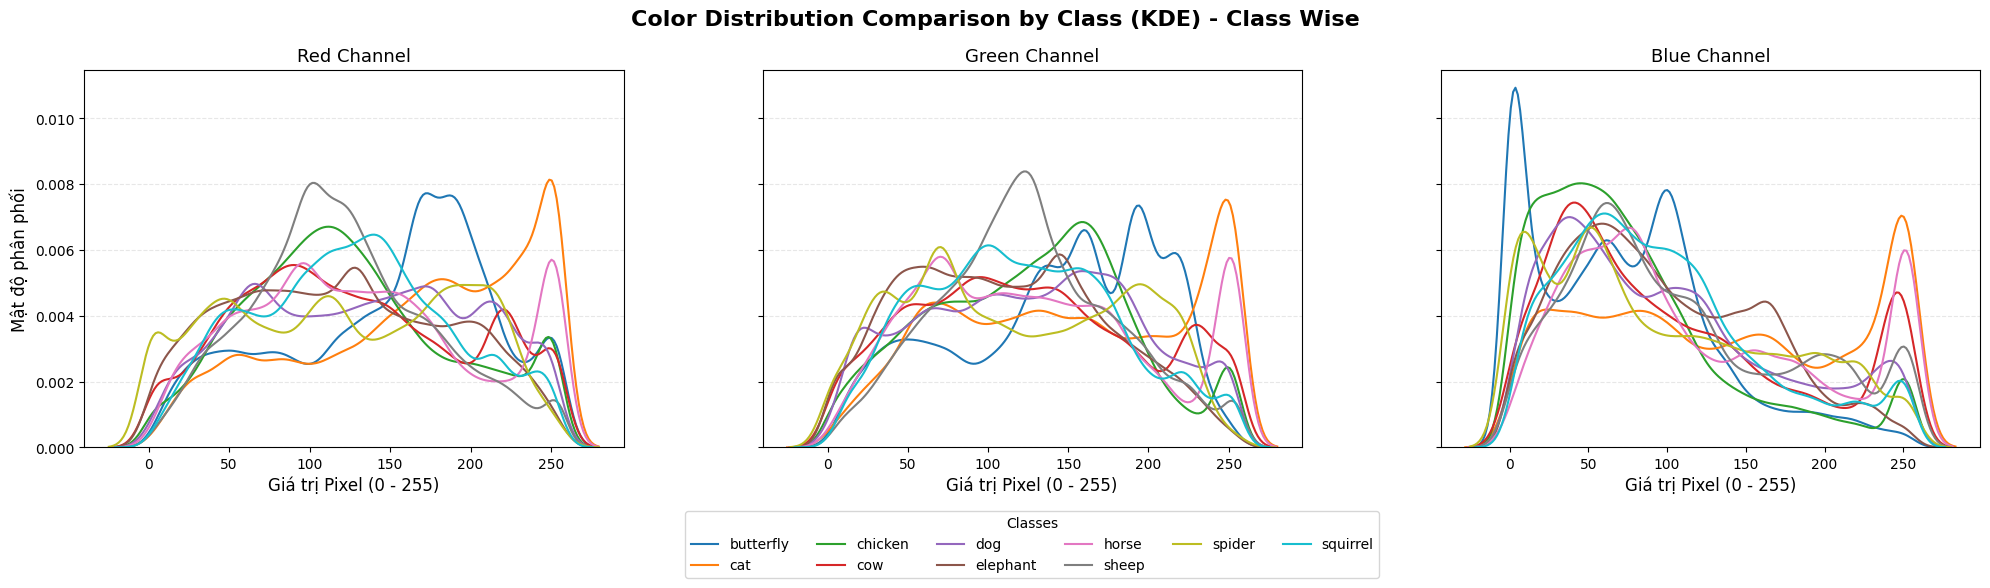

In [4]:
print("\n--- PHÂN PHỐI KDE THEO TỪNG CLASS ---")
plot_distribution_by_class(images, labels, class_names, title_suffix="- Class Wise")

# Đánh giá phân phối theo Class: Khám phá bản chất dữ liệu

Biểu đồ KDE phân rã theo từng Class giúp giải mã chính xác nguyên nhân đằng sau sự mất cân bằng màu của toàn bộ tập dữ liệu, đây vốn là câu hỏi không thể trả lời nếu chỉ nhìn vào Histogram tổng.

**1. Giải thích sự phân bố tổng quan bằng phân phối cục bộ:**
* **Tại sao tổng thể kênh Red bị lệch phải?** Nhìn vào biểu đồ KDE Class-wise (Red Channel), ta thấy các đường cong của lớp `cat` (màu cam), `horse` (màu hồng), và một số lớp động vật khác có đỉnh nhô rất cao ở dải sáng (`> 200`). Chính sự đóng góp cộng dồn của nhóm các con vật có bộ lông màu nâu/vàng/cam này đã kéo lệch đường KDE tổng thể của kênh Red sang phải.
* **Tại sao tổng thể kênh Blue bị lệch trái cực đoan?**
  Tại biểu đồ KDE Class-wise (Blue Channel), xuất hiện một đường cong (màu xanh dương đậm của lớp `butterfly` và một số lớp khác) có đỉnh vọt lên cực kỳ cao ở sát mốc `0`. Các pixel xanh dương tối này đã làm "biến dạng" phân phối tổng thể, tạo ra đỉnh nhọn ở vùng tối của kênh Blue mà ta thấy ở phần đánh giá KDE.
* **Cột cháy sáng 255 đến từ đâu?**
  Biểu đồ Class-wise cho thấy ở dải `~250-255`, nhiều lớp (đặc biệt là kênh Blue và Red) đồng loạt vọt đỉnh phụ. Điều này củng cố giả thuyết rằng Dataset có nhiều lớp ảnh được chụp trên phông nền nhân tạo trắng xóa.

**2. Kết luận: Histogram toàn bộ Dataset CÓ PHẢN ÁNH ĐÚNG bản chất phân phối dữ liệu không?**
* **Câu trả lời là KHÔNG.** Histogram trên toàn tập dữ liệu chỉ biểu thị một bức tranh "trung bình cộng" bị nhiễu. Nó gộp chung đặc điểm ngữ nghĩa của các lớp khác nhau thành một.
* Nếu chỉ dựa vào Histogram tổng và kết luận *"Dataset bị ám đỏ, cần phải giảm kênh Red"*, ta sẽ phạm sai lầm nghiêm trọng. Sự "ám đỏ" ở đây không phải do lỗi của thiết bị chụp hình hay điều kiện thiếu sáng, mà là **đặc điểm tự nhiên bản chất** của chính các lớp dữ liệu (chó, ngựa, mèo lông vàng).
* **Định hướng tiền xử lý:** Việc phân tích và đưa ra quyết định tiền xử lý ảnh (ví dụ: cân bằng màu - Color Constancy, Histogram Equalization) **bắt buộc phải được kiểm tra cẩn thận ở mức độ từng lớp**. Tránh việc áp dụng các bộ lọc chuẩn hóa không đúng bản chất làm mất đi đặc trưng màu sắc tự nhiên vốn rất quan trọng để mô hình Machine Learning phân loại chính xác các con vật.